<a href="https://colab.research.google.com/github/mejian1/CLASS_2023/blob/master/mergingDatasetsMay222025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required packages (run in Colab)
!pip install openpyxl seaborn matplotlib pandas

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---- 1. Mount Google Drive to access files (if needed) ----
from google.colab import drive
drive.mount('/content/drive')

# ---- 2. Load your datasets ----
# Example file paths (adjust these to your actual files in Google Drive)
wt_file = '/content/drive/MyDrive/your_folder/wildtype_fasting_log2fc.csv'
mdt15_file = '/content/drive/MyDrive/your_folder/mdt15_log2fc.csv'
sbp1_file = '/content/drive/MyDrive/your_folder/sbp1_log2fc.csv'
timeseries_file = '/content/drive/MyDrive/your_folder/timeseries_rnaseq.csv'

# Load data
wt = pd.read_csv(wt_file)
mdt15 = pd.read_csv(mdt15_file)
sbp1 = pd.read_csv(sbp1_file)
timeseries = pd.read_csv(timeseries_file)

# ---- 3. Merge datasets on gene_id ----
df = wt.merge(mdt15, on='gene_id', how='inner').merge(sbp1, on='gene_id', how='inner')
df = df.merge(timeseries, on='gene_id', how='inner')

# ---- 4. Select and normalize columns for heatmap ----
# Select columns for heatmap (adjust as needed)
heatmap_cols = ['log2FC_wt', 'log2FC_mdt15', 'log2FC_sbp1'] + [col for col in timeseries.columns if col != 'gene_id']
heatmap_data = df.set_index('gene_id')[heatmap_cols]

# Z-score normalization by gene (row)
heatmap_data = heatmap_data.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# Optionally, filter for genes of interest (e.g., top variable genes)
top_n = 50  # adjust as needed
gene_variance = heatmap_data.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(top_n).index
plot_data = heatmap_data.loc[top_genes]

# ---- 5. Create a high-quality, publication-ready heatmap ----
sns.set(font_scale=1.2, style='white')
plt.figure(figsize=(14, 16))
g = sns.clustermap(
    plot_data,
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    figsize=(12,14),
    col_cluster=True,
    row_cluster=True,
    dendrogram_ratio=(.1, .2),
    cbar_pos=(0.02, 0.8, 0.03, 0.18),
    xticklabels=True,
    yticklabels=True
)
plt.title('Integrated Gene Expression Heatmap (Fed vs Fasting, RNAi, Time Series)', fontsize=18, pad=80)
plt.savefig('/content/drive/MyDrive/your_folder/publishable_heatmap.png', dpi=400, bbox_inches='tight')
plt.show()


In [ ]:
#Code is for cleaning probeID to gene ID microarray gene expression dataset sbp-1(RNAi) vs EV control
import pandas as pd

# Load your CSV file
df = pd.read_csv("/content/sbp1_RNAi_probeID2GeneID.csv")  # Replace with your actual filename

# Function to parse the gene_assignment column
def parse_gene_assignment(row):
    entries = str(row).split("///")
    parsed_entries = []
    for entry in entries:
        parts = [part.strip() for part in entry.split("//")]
        if len(parts) == 5:
            parsed_entries.append(parts)
    return parsed_entries

# Apply parsing and flatten
parsed_data = df["gene_assignment"].apply(parse_gene_assignment)
flattened = [item for sublist in parsed_data for item in sublist]

# Create structured DataFrame
columns = ["ID", "Name", "Type", "Placeholder", "Code"]
structured_df = pd.DataFrame(flattened, columns=columns)

# Save to CSV
structured_df.to_csv("parsed_gene_assignments.csv", index=False)


In [ ]:
import pandas as pd

# Assuming your files are in the Colab session storage,
# you can access them directly by their names.
file1_name = '/content/sbp1_DGEs.csv'  # Replace with the actual name of your first file
file2_name = '/content/sbp1_RNAi_probeID2GeneID.csv'  # Replace with the actual name of your second file

# Load datasets
try:
    df1 = pd.read_csv(file1_name)
    df2 = pd.read_csv(file2_name)
except FileNotFoundError:
    print("Make sure your file names are correct and the files are in the session storage.")
    # You might want to exit or handle this error appropriately
    exit()

# Define the columns to merge on.
# Replace 'ID_col_df1', 'Gene_Assignment_col_df1' with the actual column names in dataset1
# Replace 'ID_col_df2', 'Gene_Assignment_col_df2' with the actual column names in dataset2
# Make sure the column names are consistent across both dataframes for a clean merge
# If the column names are different, you'll need to rename them before merging.
merge_cols_df1 = ['ID', 'gene_assignment']
merge_cols_df2 = ['ID', 'gene_assignment']

# Optional: Rename columns in df2 to match df1 if necessary
# Example:
# df2 = df2.rename(columns={'ID_col_df2': 'ID_col_df1', 'Gene_Assignment_col_df2': 'Gene_Assignment_col_df1'})

# Merge the datasets
# Using an inner join to keep only rows where the merge columns match in both datasets
merged_df = df1.merge(df2, on=merge_cols_df1, how='inner')

# Display the first few rows of the merged dataset
print(merged_df.head())

# Optional: Save the merged dataset back to the session storage
# output_file_name = 'merged_dataset.csv'
# merged_df.to_csv(output_file_name, index=False)
# prompt: I have two datasets one consists of differentially expressed genes (DGEs) TopTable of sbp-1(RNAi) vs EV control in c. elegans worms and the second dataset consist of probe ID to gene ID annotation dataset and I want to map the probe ID (DGE dataset) to gene_assignment (probeID to gene ID annotation dataset)

#import pandas as pd
# Assume the sbp1 dataset is already loaded and named 'sbp1'
# Assume the probe ID to gene ID annotation dataset is loaded and named 'probe_annotation'

# Example: Load the probe annotation file (adjust path and format as needed)
# If your annotation file is a CSV:
# probe_annotation = pd.read_csv('/content/drive/MyDrive/your_folder/probe_annotation.csv')
# If your annotation file is an Excel file:
#probe_annotation_file = '/content/drive/MyDrive/your_folder/probe_annotation.xlsx'
#probe_annotation = pd.read_excel(probe_annotation_file)


# Identify the columns in each dataframe to use for merging
# Assuming 'probe_id' is the common column in sbp1
# Assuming 'probe_ID' is the column with probe IDs in probe_annotation
# Assuming 'gene_assignment' is the column with gene IDs in probe_annotation

# Rename columns in probe_annotation to match sbp1 if necessary for a clean merge
# Example: If the probe ID column in probe_annotation is 'Probe_ID', rename it to 'probe_id'
if 'Probe_ID' in probe_annotation.columns:
    probe_annotation = probe_annotation.rename(columns={'Probe_ID': 'probe_id'})
# Example: If the gene ID column in probe_annotation is 'Gene_Assignment', rename it to 'gene_assignment'
if 'Gene_Assignment' in probe_annotation.columns:
    probe_annotation = probe_annotation.rename(columns={'Gene_Assignment': 'gene_assignment'})


# Merge the sbp1 dataset with the probe annotation dataset
# We will use an inner join to keep only the probes that are present in both datasets
sbp1_annotated = sbp1.merge(probe_annotation[['ID', 'gene_assignment']], on='probe_id', how='left')

# Now 'sbp1_annotated' contains the original sbp1 data plus the 'gene_assignment' column
# You can inspect the merged dataframe
print(sbp1_annotated.head())

# Optional: Handle probes that did not have a matching gene assignment
# For example, fill missing gene assignments with a placeholder or drop rows
# sbp1_annotated['gene_assignment'] = sbp1_annotated['gene_assignment'].fillna('No_Gene_Match')
# sbp1_annotated = sbp1_annotated.dropna(subset=['gene_assignment'])

# Optional: Further analysis or processing with the annotated data
# For example, group by gene_assignment to consolidate results if multiple probes map to one gene
# sbp1_annotated.groupby('gene_assignment').agg({'log2FC': 'mean', 'pvalue': 'min'})

```

SyntaxError: invalid syntax (<ipython-input-7-ce4e9e1e7dc6>, line 84)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from scipy.stats import hypergeom

# Example gene sets (replace with your actual gene sets)
mdt15_downregulated = {'geneA', 'geneB', 'geneC', 'geneD', 'geneE'}
fasted_downregulated = {'geneC', 'geneD', 'geneF', 'geneG'}

# Define platform size
platform_size = 18286

# Compute overlaps
overlap = mdt15_downregulated & fasted_downregulated
k = len(overlap)
M = platform_size                  # Total genes
n = len(mdt15_downregulated)      # Successes in population
N = len(fasted_downregulated)     # Sample size

# Hypergeometric P-value: probability of >= k overlap by chance
p_value = hypergeom.sf(k - 1, M, n, N)

# Print statistics
print(f"Overlap: {k} genes")
print(f"Hypergeometric P-value: {p_value:.2e}")

# Create Venn diagram
venn2([mdt15_downregulated, fasted_downregulated],
      set_labels=('mdt-15(RNAi) down', '6hr Fasted down'))

# Annotate p-value
plt.title(f"Overlap of Downregulated Genes\nHypergeometric P = {p_value:.2e}")
plt.show()


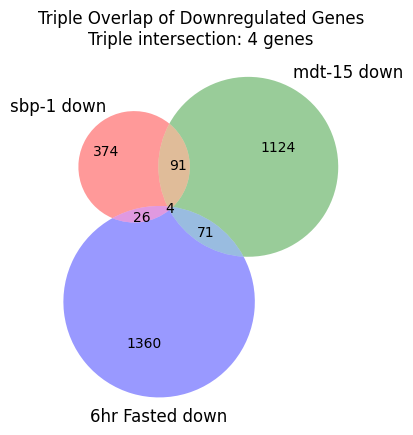

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Load the CSV
df = pd.read_csv("/content/tripletintersectionfasting.csv")

# Convert each column to a set of gene IDs (drop NA)
sbp1_genes = set(df['sbp-1TopTable.WBIDs'].dropna())
mdt15_genes = set(df['mdt-15downreg.WBIDs'].dropna())
fasted_genes = set(df['6-hour fasting'].dropna())

# Calculate triple intersection
triple_overlap = sbp1_genes & mdt15_genes & fasted_genes

# Plot Venn diagram
venn3([sbp1_genes, mdt15_genes, fasted_genes],
      set_labels=('sbp-1 down', 'mdt-15 down', '6hr Fasted down'))
plt.title(f"Triple Overlap of Downregulated Genes\nTriple intersection: {len(triple_overlap)} genes")
plt.show()
